In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv("CLEAN_dataset.csv")
df

,parent_count,files_changed,additions,deletions,total_changes,message_length,commit_hour,commit_day,developer_experience,directories_changed,buggy_label
0,1,1,4,0,4,98,14,1,0,1,0
1,1,11,554,13,567,638,13,1,0,1,0
2,1,2,946,0,946,938,13,1,0,1,0
3,1,7,166,207,373,420,13,1,0,1,0
4,1,2,52,1,53,2442,13,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...
9994,1,4,147,79,226,183,8,0,71,1,1
9995,1,15,12,49,61,54,8,0,0,2,1
9996,1,7,519,152,671,549,15,4,72,3,0
9997,1,1,1,1,2,614,14,4,370,1,1


In [ ]:
X = df.drop("buggy_label", axis=1)
y = df["buggy_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## **Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
# Base model
lr = LogisticRegression(random_state=42, max_iter=1000)

In [ ]:
# Hyperparameter grid
params = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"],
    "max_iter": [500, 1000]
}

In [ ]:
# Grid search with cross validation
grid = GridSearchCV(
    estimator=lr,
    param_grid=params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [ ]:
# Train
grid.fit(X_train, y_train)

In [ ]:
# Best model
best_lr = grid.best_estimator_

In [ ]:
print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid.best_score_)

In [ ]:
# Predictions
y_pred = best_lr.predict(X_test)

In [ ]:
# Evaluation
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
cm        = confusion_matrix(y_test, y_pred)

print("\nFinal Test Results:")
print("Accuracy: ",  accuracy)
print("Precision:", precision)
print("Recall:   ", recall)
print("F1-score: ", f1)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

## **Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
# base model
dt = DecisionTreeClassifier(random_state=42)

In [ ]:
# hyperparameter grid
params = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 3, 5]
}

In [ ]:
# grid search with cross validation
grid = GridSearchCV(
    estimator=dt,
    param_grid=params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [ ]:
# train
grid.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10, 15, None],
                         'min_samples_leaf': [1, 3, 5],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [ ]:
# best model
best_dt = grid.best_estimator_

In [ ]:

print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid.best_score_)


Best Parameters:
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Cross-Validation Accuracy:
0.6422063789868668


In [ ]:
# predictions
y_pred = best_dt.predict(X_test)


In [ ]:
# evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\nFinal Test Results:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Final Test Results:
Accuracy: 0.653
Precision: 0.6496815286624203
Recall: 0.5489773950484392
F1-score: 0.5950991831971996

Confusion Matrix:
[[796 275]
 [419 510]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.74      0.70      1071
           1       0.65      0.55      0.60       929

    accuracy                           0.65      2000
   macro avg       0.65      0.65      0.65      2000
weighted avg       0.65      0.65      0.65      2000



## **Random Forest**

## **SVM**

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = SVC(kernel='linear')
model.fit(X_train, y_train)

SVC(kernel='linear')

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 0.5955
              precision    recall  f1-score   support

           0       0.58      0.93      0.71      1071
           1       0.71      0.22      0.33       929

    accuracy                           0.60      2000
   macro avg       0.65      0.57      0.52      2000
weighted avg       0.64      0.60      0.53      2000



## **ANN**

In [ ]:
!pip install tensorflow

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras import models
from keras import layers
from keras import optimizers
from sklearn.preprocessing import StandardScaler


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 32)                  │             352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5112 - loss: 0.7526 - val_accuracy: 0.5456 - val_loss: 0.6869
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5331 - loss: 0.7050 - val_accuracy: 0.5437 - val_loss: 0.6877
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5338 - loss: 0.6969 - val_accuracy: 0.5412 - val_loss: 0.6885
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5418 - loss: 0.6921 - val_accuracy: 0.5425 - val_loss: 0.6883
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5459 - loss: 0.6910 - val_accuracy: 0.5444 - val_loss: 0.6875
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5535 - loss: 0.6869 - val_accuracy: 0.5512 - val_loss: 0.6842
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5485 - loss: 0.6888 - val_accuracy: 0.5562 - val_loss: 0.6817
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5540 - loss: 0.6878 - val_accuracy: 0.

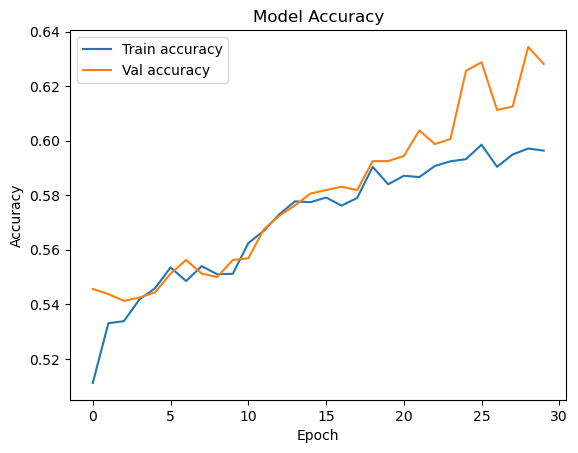

In [ ]:
# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Build the model
model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.5))
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(8, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Classification report
y_pred = (model.predict(X_test) >= 0.5).astype(int)
print(classification_report(y_test, y_pred, target_names=['Not Buggy', 'Buggy']))

# Plot training history
plt.plot(history.history['accuracy'],     label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Val accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 64)                  │             704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5379 - loss: 0.6922 - val_accuracy: 0.5956 - val_loss: 0.6705
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5763 - loss: 0.6814 - val_accuracy: 0.6112 - val_loss: 0.6594
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5898 - loss: 0.6723 - val_accuracy: 0.6475 - val_loss: 0.6531
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6029 - loss: 0.6670 - val_accuracy: 0.6363 - val_loss: 0.6453
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6146 - loss: 0.6653 - val_accuracy: 0.6363 - val_loss: 0.6428
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6163 - loss: 0.6621 - val_accuracy: 0.6394 - val_loss: 0.6391
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6171 - loss: 0.6565 - val_accuracy: 0.6369 - val_loss: 0.6384
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6285 - loss: 0.6529 - val_accuracy: 0.

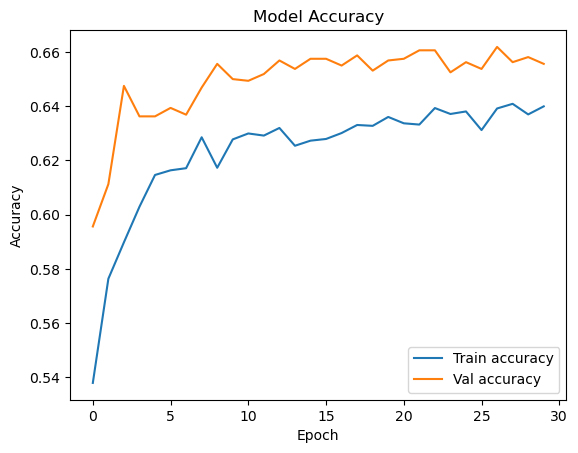

In [ ]:
# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

#the model
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2)

# Evaluation
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Classification report
y_pred = (model.predict(X_test) >= 0.5).astype(int) #threshold
print(classification_report(y_test, y_pred, target_names=['Not Buggy', 'Buggy']))

# Plot training history
plt.plot(history.history['accuracy'],     label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Val accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## lightgbm

In [ ]:
!pip install lightgbm

In [ ]:
import warnings
warnings.filterwarnings('ignore')

from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay)
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pandas as pd


In [ ]:
param_grid = {
    'n_estimators'     : [100, 200, 300],
    'num_leaves'       : [31, 63, 127],
    'learning_rate'    : [0.05, 0.1, 0.2],
    'min_child_samples': [20, 50],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    LGBMClassifier(random_state=42, verbosity=-1),
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train)

print(f"\nBest params  : {grid_search.best_params_}")
print(f"Best AUC-ROC (CV): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best params  : {'learning_rate': 0.05, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31}
Best AUC-ROC (CV): 0.6950



Tuned LightGBM — Test set
  Accuracy : 0.6495
  F1       : 0.5769
  AUC-ROC  : 0.6965

              precision    recall  f1-score   support

   Not Buggy       0.65      0.77      0.70      1071
       Buggy       0.66      0.51      0.58       929

    accuracy                           0.65      2000
   macro avg       0.65      0.64      0.64      2000
weighted avg       0.65      0.65      0.64      2000



Text(0.5, 1.0, 'Confusion matrix')

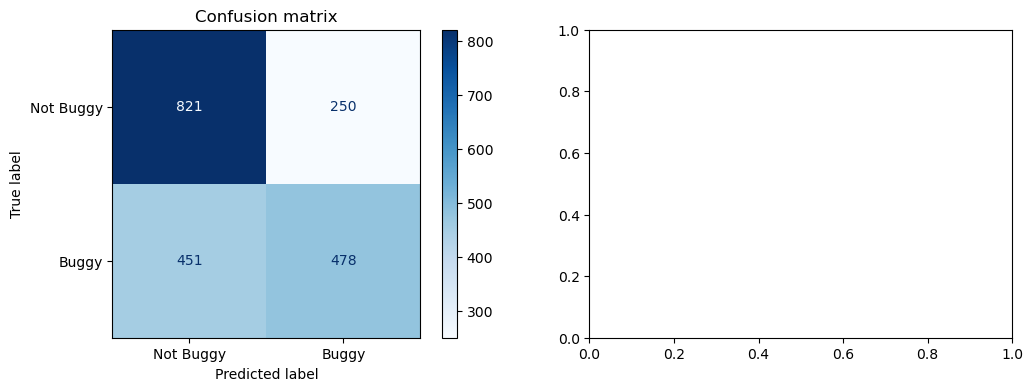

In [ ]:
best = grid_search.best_estimator_

y_pred = best.predict(X_test)
y_prob = best.predict_proba(X_test)[:, 1]

print("\nTuned LightGBM — Test set")
print(f"  Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"  F1       : {f1_score(y_test, y_pred):.4f}")
print(f"  AUC-ROC  : {roc_auc_score(y_test, y_prob):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Not Buggy', 'Buggy']))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Not Buggy', 'Buggy'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion matrix')

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best params  : {'learning_rate': 0.05, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31}
Best AUC-ROC : 0.6948



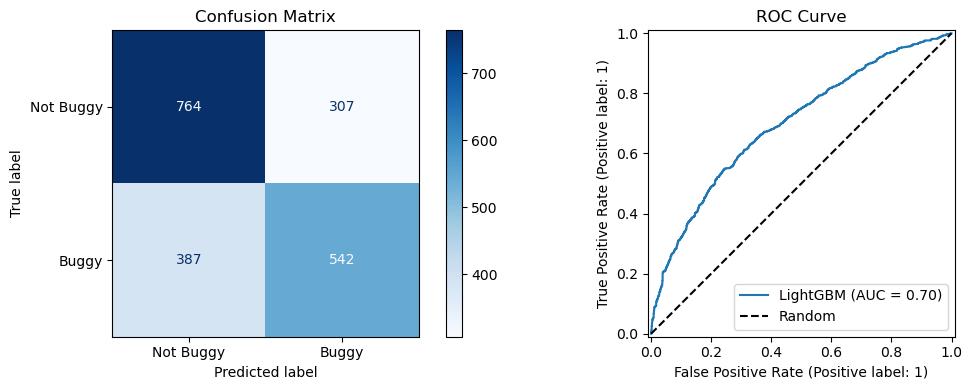

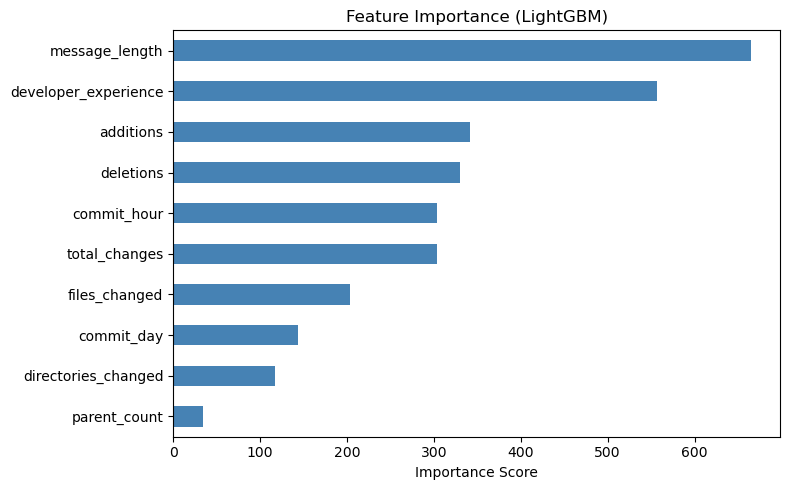

In [ ]:
# Class weights
weights = compute_class_weight(class_weight='balanced',
                               classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: weights[0], 1: weights[1]} #increses the recall of buggy

# GridSearchCV tuning
param_grid = {
    'n_estimators'     : [100, 200, 300],
    'num_leaves'       : [31, 63, 127],
    'learning_rate'    : [0.05, 0.1, 0.2],
    'min_child_samples': [20, 50],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    LGBMClassifier(random_state=42, verbosity=-1, class_weight=class_weight_dict),
    param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1,
)
grid_search.fit(X_train, y_train)
print(f"Best params  : {grid_search.best_params_}")
print(f"Best AUC-ROC : {grid_search.best_score_:.4f}\n")





Tuned LightGBM — Test set
  Accuracy : 0.6530
  F1       : 0.6097
  AUC-ROC  : 0.6991

              precision    recall  f1-score   support

   Not Buggy       0.66      0.71      0.69      1071
       Buggy       0.64      0.58      0.61       929

    accuracy                           0.65      2000
   macro avg       0.65      0.65      0.65      2000
weighted avg       0.65      0.65      0.65      2000



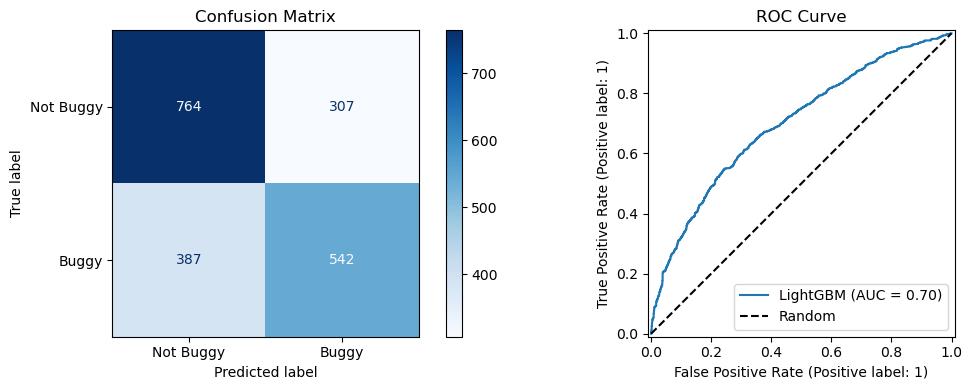

In [ ]:
best = grid_search.best_estimator_
y_pred = best.predict(X_test)
y_prob = best.predict_proba(X_test)[:, 1]
best = grid_search.best_estimator_

y_pred = best.predict(X_test)
y_prob = best.predict_proba(X_test)[:, 1]

print("\nTuned LightGBM — Test set")
print(f"  Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"  F1       : {f1_score(y_test, y_pred):.4f}")
print(f"  AUC-ROC  : {roc_auc_score(y_test, y_prob):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Not Buggy', 'Buggy']))
# Confusion matrix + ROC curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Not Buggy', 'Buggy'], cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix')
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], name='LightGBM')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_title('ROC Curve')
axes[1].legend()
plt.tight_layout()
plt.show()


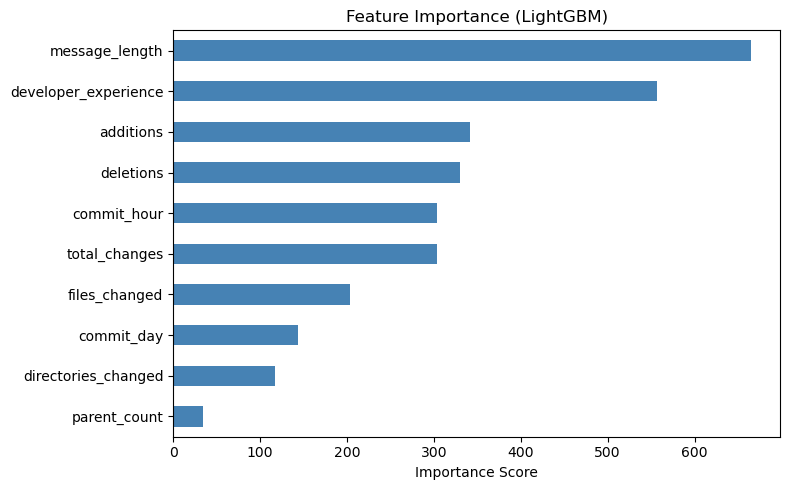

In [ ]:
# Feature importance
fi = pd.Series(best.feature_importances_, index=X.columns).sort_values()
fi.plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title('Feature Importance (LightGBM)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


# Random Forest

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [15]:
df = pd.read_csv("CLEAN_dataset.csv")

X = df.drop("buggy_label", axis=1)
y = df["buggy_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
# Base model
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

In [17]:
# Hyperparameter grid
params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [18]:
# Grid search with cross validation
grid = GridSearchCV(
    estimator=rf,
    param_grid=params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [19]:
# Train
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [20]:
# Best model
best_rf = grid.best_estimator_

In [21]:
# Predictions
y_pred = best_rf.predict(X_test)

In [22]:
# Evaluation
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
cm        = confusion_matrix(y_test, y_pred)

print("\nFinal Test Results:")
print("Accuracy: ",  accuracy)
print("Precision:", precision)
print("Recall:   ", recall)
print("F1-score: ", f1)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Final Test Results:
Accuracy:  0.659
Precision: 0.6717663421418637
Recall:    0.5199138858988159
F1-score:  0.5861650485436893

Confusion Matrix:
[[835 236]
 [446 483]]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.78      0.71      1071
           1       0.67      0.52      0.59       929

    accuracy                           0.66      2000
   macro avg       0.66      0.65      0.65      2000
weighted avg       0.66      0.66      0.65      2000



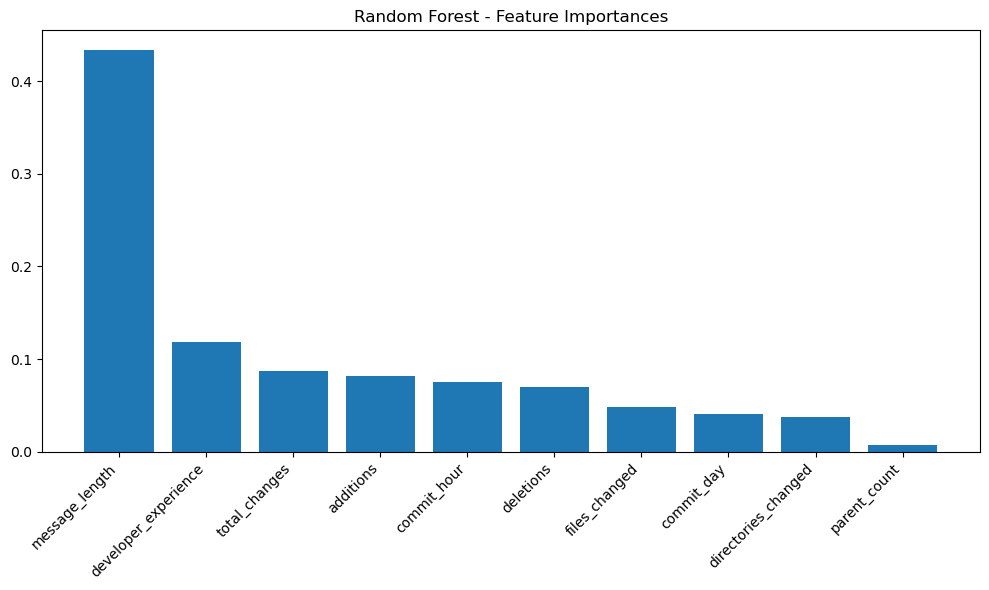


Feature Importances (sorted):
  message_length            0.4330
  developer_experience      0.1189
  total_changes             0.0866
  additions                 0.0812
  commit_hour               0.0749
  deletions                 0.0703
  files_changed             0.0488
  commit_day                0.0408
  directories_changed       0.0379
  parent_count              0.0076


In [23]:
# Feature Importance
import matplotlib.pyplot as plt
import numpy as np

importances = best_rf.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Random Forest - Feature Importances")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), feature_names[indices], rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\nFeature Importances (sorted):")
for i in indices:
    print(f"  {feature_names[i]:<25} {importances[i]:.4f}")